<a href="https://colab.research.google.com/github/workhendry20-creator/data-analyst-portfolio/blob/main/Analisis_Sentimen_TJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Instal Google Play Scraper**

In [ ]:
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.3 MB/s eta 0:00:00


**Import Library**

In [ ]:
from google_play_scraper import reviews, Sort, reviews_all
import pandas as pd
import time

**Scraping Data TransJakarta**

In [ ]:
result = reviews_all(
    'com.transjakmobile',
    lang='id',
    country='id',
    sort=Sort.NEWEST
)

df = pd.DataFrame(result)
print("Jumlah data mentah:", len(df))

Jumlah data mentah: 4431


**Filter per 1 Mei 2025**

In [ ]:
import pandas as pd

df['at'] = pd.to_datetime(df['at'])
# Filter hanya data dari 1 Mei 2025
df = df[df['at'] >= '2025-05-01'].copy()
df = df[['content', 'score', 'at']]
df = df.drop_duplicates(subset=['content'])
df = df.sort_values(by='at', ascending=True).reset_index(drop=True)

print(f"Jumlah data setelah filter: {len(df)} ulasan")
print(f"Rentang Tanggal: {df['at'].min()} sampai {df['at'].max()}")
df.head()

Jumlah data setelah filter: 2531 ulasan
Rentang Tanggal: 2025-05-01 00:36:37 sampai 2026-05-18 05:16:43


,content,score,at
0,pembayaran hanya via astra pay...kirain top up...,1,2025-05-01 00:36:37
1,app transjakarta ini memudahkan banget buat ak...,5,2025-05-01 15:15:29
2,Pernah hampir telat wawancara kerja. Untung bu...,5,2025-05-01 17:50:45
3,aplikasi yang mudah dipakai dan sangat bermanfaat,5,2025-05-01 22:02:16
4,Aplikasi ini memungkinkan pengguna untuk meman...,5,2025-05-01 22:16:12


**Cek Distribusi Rating**

In [ ]:
df['score'].value_counts().sort_index()

,count
score,
1,367
2,83
3,70
4,53
5,1958


**Save File Dataset**

In [ ]:
df.to_csv('ulasan_transjakarta_2025-2026.csv', index=False)

**CLEANING**

**Import Library**

In [ ]:
import pandas as pd
import re

**Load Dataset**

In [ ]:
df = pd.read_csv('/content/ulasan_transjakarta_2025-2026.csv')

df.head()

,content,score,at
0,pembayaran hanya via astra pay...kirain top up...,1,2025-05-01 00:36:37
1,app transjakarta ini memudahkan banget buat ak...,5,2025-05-01 15:15:29
2,Pernah hampir telat wawancara kerja. Untung bu...,5,2025-05-01 17:50:45
3,aplikasi yang mudah dipakai dan sangat bermanfaat,5,2025-05-01 22:02:16
4,Aplikasi ini memungkinkan pengguna untuk meman...,5,2025-05-01 22:16:12


In [ ]:
df.columns

Index(['content', 'score', 'at'], dtype='object')

In [ ]:
print("Jumlah data awal:", len(df))

Jumlah data awal: 2531


In [ ]:
df = df.dropna(subset=['content'])
df = df.reset_index(drop=True)

print("Jumlah data setelah hapus data kosong:", len(df))

Jumlah data setelah hapus data kosong: 2531


In [ ]:
def cleaning_text(text):
    text = str(text)

    # hapus URL
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)

    # hapus mention
    text = re.sub(r'@\w+', ' ', text)

    # hapus hashtag, tapi teksnya tetap diambil
    text = re.sub(r'#', '', text)

    # hapus angka
    text = re.sub(r'\d+', ' ', text)

    # hapus tanda baca dan karakter khusus
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
df['cleaning'] = df['content'].apply(cleaning_text)

df[['content', 'cleaning']].head(10)

,content,cleaning
0,pembayaran hanya via astra pay...kirain top up...,pembayaran hanya via astra pay kirain top up m...
1,app transjakarta ini memudahkan banget buat ak...,app transjakarta ini memudahkan banget buat ak...
2,Pernah hampir telat wawancara kerja. Untung bu...,Pernah hampir telat wawancara kerja Untung buk...
3,aplikasi yang mudah dipakai dan sangat bermanfaat,aplikasi yang mudah dipakai dan sangat bermanfaat
4,Aplikasi ini memungkinkan pengguna untuk meman...,Aplikasi ini memungkinkan pengguna untuk meman...
5,Aplikasi Transjakarta sangat membantu untuk mo...,Aplikasi Transjakarta sangat membantu untuk mo...
6,Aplikasi Transjakarta bener bener ngebantu ban...,Aplikasi Transjakarta bener bener ngebantu ban...
7,setelah ada transjakarta jdi enak,setelah ada transjakarta jdi enak
8,Aplikasi Tj Transjakarta sangat membantu dalam...,Aplikasi Tj Transjakarta sangat membantu dalam...
9,Aplikasi Transjakarta sangat membantu saya dal...,Aplikasi Transjakarta sangat membantu saya dal...


In [ ]:
df = df[df['cleaning'].str.strip() != '']
df = df.reset_index(drop=True)

print("Jumlah data setelah cleaning:", len(df))

Jumlah data setelah cleaning: 2525


In [ ]:
df.to_csv('hasil_cleaning.csv', index=False)

print("File hasil cleaning berhasil disimpan.")

File hasil cleaning berhasil disimpan.


In [ ]:
df[['content', 'cleaning']].head(5)

,content,cleaning
0,pembayaran hanya via astra pay...kirain top up...,pembayaran hanya via astra pay kirain top up m...
1,app transjakarta ini memudahkan banget buat ak...,app transjakarta ini memudahkan banget buat ak...
2,Pernah hampir telat wawancara kerja. Untung bu...,Pernah hampir telat wawancara kerja Untung buk...
3,aplikasi yang mudah dipakai dan sangat bermanfaat,aplikasi yang mudah dipakai dan sangat bermanfaat
4,Aplikasi ini memungkinkan pengguna untuk meman...,Aplikasi ini memungkinkan pengguna untuk meman...


**Case Folding**

In [ ]:
def case_folding(text):
    # Mengubah semua karakter menjadi huruf kecil (lowercase)
    text = text.lower()
    return text

# Menerapkan Case Folding pada kolom hasil cleaning
df['case_folding'] = df['cleaning'].apply(case_folding)

# Menampilkan hasil
print("Hasil Case Folding:")
print(df[['cleaning', 'case_folding']].head())

Hasil Case Folding:
                                            cleaning  \
0  pembayaran hanya via astra pay kirain top up m...   
1  app transjakarta ini memudahkan banget buat ak...   
2  Pernah hampir telat wawancara kerja Untung buk...   
3  aplikasi yang mudah dipakai dan sangat bermanfaat   
4  Aplikasi ini memungkinkan pengguna untuk meman...   

                                        case_folding  
0  pembayaran hanya via astra pay kirain top up m...  
1  app transjakarta ini memudahkan banget buat ak...  
2  pernah hampir telat wawancara kerja untung buk...  
3  aplikasi yang mudah dipakai dan sangat bermanfaat  
4  aplikasi ini memungkinkan pengguna untuk meman...  


In [ ]:
# Menyimpan hasil tahap case folding ke file CSV
df.to_csv('hasil_case_folding.csv', index=False)

print("File 'hasil_case_folding.csv' berhasil disimpan.")

# Menampilkan 5 data teratas
df[['cleaning', 'case_folding']].head()

File 'hasil_case_folding.csv' berhasil disimpan.


,cleaning,case_folding
0,pembayaran hanya via astra pay kirain top up m...,pembayaran hanya via astra pay kirain top up m...
1,app transjakarta ini memudahkan banget buat ak...,app transjakarta ini memudahkan banget buat ak...
2,Pernah hampir telat wawancara kerja Untung buk...,pernah hampir telat wawancara kerja untung buk...
3,aplikasi yang mudah dipakai dan sangat bermanfaat,aplikasi yang mudah dipakai dan sangat bermanfaat
4,Aplikasi ini memungkinkan pengguna untuk meman...,aplikasi ini memungkinkan pengguna untuk meman...


**Normalisasi**

In [ ]:
import pandas as pd
import os

# Nama file sesuai yang kamu upload
path_kamus = "kamus.csv"

if os.path.exists(path_kamus):
    # Menggunakan 'utf-8-sig' untuk menghapus karakter ï»¿ otomatis
    # sep=None agar pandas otomatis mendeteksi pemisah koma atau titik koma
    kamus_df = pd.read_csv(path_kamus, encoding='utf-8-sig', sep=None, engine='python')

    # Membersihkan nama kolom (kecilkan huruf dan hapus spasi)
    kamus_df.columns = [c.strip().lower() for c in kamus_df.columns]

    # Cek apakah kolom sudah benar
    if 'singkatan' in kamus_df.columns and 'asli' in kamus_df.columns:
        # Buat kamus pemetaan
        kamus_dict = dict(zip(kamus_df['singkatan'].astype(str), kamus_df['asli'].astype(str)))

        def normalization(text):
            if pd.isna(text): return ""
            words = str(text).split()
            # Cari kata di kamus, jika tidak ada pakai kata aslinya
            return ' '.join([kamus_dict.get(word, word) for word in words])

        # Eksekusi pada kolom case_folding
        df['normalization'] = df['case_folding'].apply(normalization)

        print("✅ Berhasil! Normalisasi selesai tanpa error karakter.")
        display(df[['case_folding', 'normalization']].head())
    else:
        print("❌ Kolom tidak ditemukan!")
        print("Kolom yang terbaca sistem adalah:", list(kamus_df.columns))
else:
    print(f"❌ File '{path_kamus}' tidak ditemukan di panel Files.")

✅ Berhasil! Normalisasi selesai tanpa error karakter.


,case_folding,normalization
0,pembayaran hanya via astra pay kirain top up m...,pembayaran hanya via astra pay kirain top up m...
1,app transjakarta ini memudahkan banget buat ak...,aplikasi transjakarta ini memudahkan sangat bu...
2,pernah hampir telat wawancara kerja untung buk...,pernah hampir telat wawancara kerja untung buk...
3,aplikasi yang mudah dipakai dan sangat bermanfaat,aplikasi yang mudah dipakai dan sangat bermanfaat
4,aplikasi ini memungkinkan pengguna untuk meman...,aplikasi ini memungkinkan pengguna untuk meman...


In [ ]:
# Menyimpan hasil sementara ke CSV
df.to_csv('hasil_normalisasi.csv', index=False)
df[['cleaning', 'case_folding','normalization']].head()

,cleaning,case_folding,normalization
0,pembayaran hanya via astra pay kirain top up m...,pembayaran hanya via astra pay kirain top up m...,pembayaran hanya via astra pay kirain top up m...
1,app transjakarta ini memudahkan banget buat ak...,app transjakarta ini memudahkan banget buat ak...,aplikasi transjakarta ini memudahkan sangat bu...
2,Pernah hampir telat wawancara kerja Untung buk...,pernah hampir telat wawancara kerja untung buk...,pernah hampir telat wawancara kerja untung buk...
3,aplikasi yang mudah dipakai dan sangat bermanfaat,aplikasi yang mudah dipakai dan sangat bermanfaat,aplikasi yang mudah dipakai dan sangat bermanfaat
4,Aplikasi ini memungkinkan pengguna untuk meman...,aplikasi ini memungkinkan pengguna untuk meman...,aplikasi ini memungkinkan pengguna untuk meman...


**Stopword Removal**

In [ ]:
# 1. Install library Sastrawi terlebih dahulu
!pip install Sastrawi

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# 2. Inisialisasi Sastrawi Stopword
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# 3. Eksekusi pada kolom normalization
print("Sedang menghapus stopword...")
df['stopword_removal'] = df['normalization'].apply(lambda x: stopword_remover.remove(str(x)))

print("✅ Stopword Removal Selesai!")
display(df[['normalization', 'stopword_removal']].head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 2.8 MB/s eta 0:00:00
Sedang menghapus stopword...
✅ Stopword Removal Selesai!


,normalization,stopword_removal
0,pembayaran hanya via astra pay kirain top up m...,pembayaran via astra pay kirain top up moter b...
1,aplikasi transjakarta ini memudahkan sangat bu...,aplikasi transjakarta memudahkan sangat buat y...
2,pernah hampir telat wawancara kerja untung buk...,pernah hampir telat wawancara kerja untung buk...
3,aplikasi yang mudah dipakai dan sangat bermanfaat,aplikasi mudah dipakai sangat bermanfaat
4,aplikasi ini memungkinkan pengguna untuk meman...,aplikasi memungkinkan pengguna memantau posisi...


In [ ]:
# Menyimpan hasil sementara ke CSV
df.to_csv('hasil_stopword.csv', index=False)
df[['cleaning', 'case_folding','normalization','stopword_removal']].head()

,cleaning,case_folding,normalization,stopword_removal
0,pembayaran hanya via astra pay kirain top up m...,pembayaran hanya via astra pay kirain top up m...,pembayaran hanya via astra pay kirain top up m...,pembayaran via astra pay kirain top up moter b...
1,app transjakarta ini memudahkan banget buat ak...,app transjakarta ini memudahkan banget buat ak...,aplikasi transjakarta ini memudahkan sangat bu...,aplikasi transjakarta memudahkan sangat buat y...
2,Pernah hampir telat wawancara kerja Untung buk...,pernah hampir telat wawancara kerja untung buk...,pernah hampir telat wawancara kerja untung buk...,pernah hampir telat wawancara kerja untung buk...
3,aplikasi yang mudah dipakai dan sangat bermanfaat,aplikasi yang mudah dipakai dan sangat bermanfaat,aplikasi yang mudah dipakai dan sangat bermanfaat,aplikasi mudah dipakai sangat bermanfaat
4,Aplikasi ini memungkinkan pengguna untuk meman...,aplikasi ini memungkinkan pengguna untuk meman...,aplikasi ini memungkinkan pengguna untuk meman...,aplikasi memungkinkan pengguna memantau posisi...


**Tokenizing**

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

# Download kedua resource yang dibutuhkan agar tidak error lagi
nltk.download('punkt')
nltk.download('punkt_tab')

print("Sedang memproses Tokenizing...")

# Eksekusi tokenizing pada kolom stopword_removal
df['tokenizing'] = df['stopword_removal'].apply(lambda x: word_tokenize(str(x)))

print("✅ Tokenizing Selesai!")
display(df[['stopword_removal', 'tokenizing']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Sedang memproses Tokenizing...
✅ Tokenizing Selesai!


,stopword_removal,tokenizing
0,pembayaran via astra pay kirain top up moter b...,"[pembayaran, via, astra, pay, kirain, top, up,..."
1,aplikasi transjakarta memudahkan sangat buat y...,"[aplikasi, transjakarta, memudahkan, sangat, b..."
2,pernah hampir telat wawancara kerja untung buk...,"[pernah, hampir, telat, wawancara, kerja, untu..."
3,aplikasi mudah dipakai sangat bermanfaat,"[aplikasi, mudah, dipakai, sangat, bermanfaat]"
4,aplikasi memungkinkan pengguna memantau posisi...,"[aplikasi, memungkinkan, pengguna, memantau, p..."


In [ ]:
# Menyimpan hasil sementara ke CSV
df.to_csv('hasil_tokenizing.csv', index=False)
df[['cleaning', 'case_folding','normalization','stopword_removal','tokenizing']].head()

,cleaning,case_folding,normalization,stopword_removal,tokenizing
0,pembayaran hanya via astra pay kirain top up m...,pembayaran hanya via astra pay kirain top up m...,pembayaran hanya via astra pay kirain top up m...,pembayaran via astra pay kirain top up moter b...,"[pembayaran, via, astra, pay, kirain, top, up,..."
1,app transjakarta ini memudahkan banget buat ak...,app transjakarta ini memudahkan banget buat ak...,aplikasi transjakarta ini memudahkan sangat bu...,aplikasi transjakarta memudahkan sangat buat y...,"[aplikasi, transjakarta, memudahkan, sangat, b..."
2,Pernah hampir telat wawancara kerja Untung buk...,pernah hampir telat wawancara kerja untung buk...,pernah hampir telat wawancara kerja untung buk...,pernah hampir telat wawancara kerja untung buk...,"[pernah, hampir, telat, wawancara, kerja, untu..."
3,aplikasi yang mudah dipakai dan sangat bermanfaat,aplikasi yang mudah dipakai dan sangat bermanfaat,aplikasi yang mudah dipakai dan sangat bermanfaat,aplikasi mudah dipakai sangat bermanfaat,"[aplikasi, mudah, dipakai, sangat, bermanfaat]"
4,Aplikasi ini memungkinkan pengguna untuk meman...,aplikasi ini memungkinkan pengguna untuk meman...,aplikasi ini memungkinkan pengguna untuk meman...,aplikasi memungkinkan pengguna memantau posisi...,"[aplikasi, memungkinkan, pengguna, memantau, p..."


**Labelling**

/tmp/ipykernel_600/4123335326.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['at'] = pd.to_datetime(df['at'])


HASIL DISTRIBUSI SENTIMEN FINAL
label_text
Positif    1933
Negatif     530
Name: count, dtype: int64
----------------------------------------
Total Data: 2464


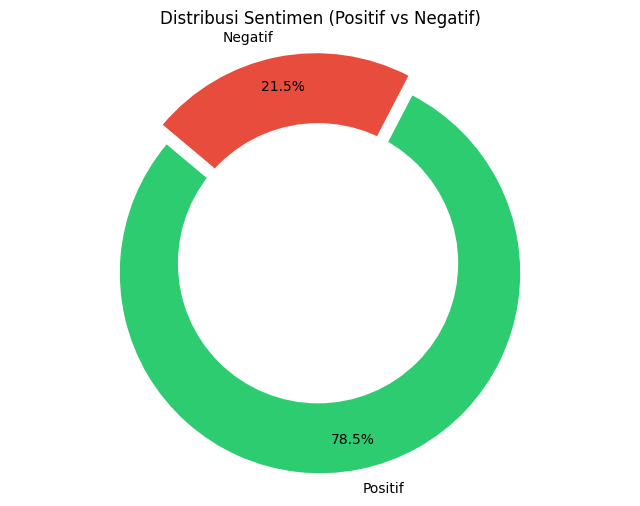

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv('Data TJ Skripsi - Sheet1.csv')

# 2. Pastikan kolom tanggal benar dan filter (Sesuaikan tanggalnya)
df['at'] = pd.to_datetime(df['at'])
df = df[df['at'] >= '2024-05-01'].copy()

# 3. Mapping Label Manual (0: Netral, 1: Positif, 2: Negatif)
label_map = {0: 'Netral', 1: 'Positif', 2: 'Negatif'}
df['label_text'] = df['label'].map(label_map)

# 4. Hapus data Netral (angka 0)
df_final = df[df['label'] != 0].copy()
df_final = df_final.reset_index(drop=True)

# --- OUTPUT UNTUK MENUNJUKKAN JUMLAH ---
print("========================================")
print("HASIL DISTRIBUSI SENTIMEN FINAL")
print("========================================")
print(df_final['label_text'].value_counts())
print("----------------------------------------")
print(f"Total Data: {len(df_final)}")
print("========================================")

# 5. Visualisasi Donut Chart
dist_final = df_final['label_text'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(dist_final, labels=dist_final.index, autopct='%1.1f%%', startangle=140,
        colors=['#2ecc71', '#e74c3c'],
        pctdistance=0.85, explode=(0.05, 0.05))

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.axis('equal')
plt.title('Distribusi Sentimen (Positif vs Negatif)')
plt.show()

# 6. Simpan hasil
df_final.to_csv('hasil_labeling.csv', index=False)

**Stemming**

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from tqdm import tqdm
import pandas as pd

# 1. Inisialisasi Stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# 2. Fungsi Stemming yang mengembalikan format List (Token)
def stemming_to_list(text):
    if isinstance(text, str):
        # Bersihkan karakter list string agar menjadi teks murni
        text = text.replace("[", "").replace("]", "").replace("'", "").replace(",", "")

        # Proses stem (menghasilkan string kalimat dasar)
        stemmed_text = stemmer.stem(text)

        # Ubah kembali menjadi list kata (token)
        return stemmed_text.split()
    return []

# 3. Proses Stemming
print("Memulai proses Stemming... Output akan berbentuk list token.")
tqdm.pandas()
df_final['stemming'] = df_final['tokenizing'].progress_apply(stemming_to_list)

# 4. Tampilkan hasil
print("\n✅ Stemming Selesai!")
print(df_final[['tokenizing', 'stemming']].head())

# 5. Simpan ke file final
df_final.to_csv('hasil_stemming.csv', index=False)

Memulai proses Stemming... Output akan berbentuk list token.


100%|██████████| 2464/2464 [02:05<00:00, 19.70it/s]


✅ Stemming Selesai!
                                          tokenizing  \
0  ['pembayaran', 'via', 'astra', 'pay', 'kirain'...   
1  ['aplikasi', 'transjakarta', 'memudahkan', 'sa...   
2  ['pernah', 'hampir', 'telat', 'wawancara', 'ke...   
3  ['aplikasi', 'mudah', 'dipakai', 'sangat', 'be...   
4  ['aplikasi', 'memungkinkan', 'pengguna', 'mema...   

                                            stemming  
0  [bayar, via, astra, pay, kirain, top, up, mote...  
1  [aplikasi, transjakarta, mudah, sangat, buat, ...  
2  [pernah, hampir, telat, wawancara, kerja, untu...  
3          [aplikasi, mudah, pakai, sangat, manfaat]  
4  [aplikasi, mungkin, guna, pantau, posisi, bus,...  


**TF IDF**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

# 1. Pastikan data bersih dari NaN
df_final = df_final.dropna(subset=['label'])

# 2. Siapkan input teks (string)
df_final['tfidf_input'] = df_final['stemming'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))

# 3. Inisialisasi dan Transformasi TF-IDF
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df_final['tfidf_input'])

# 4. Hitung akumulasi nilai TF-IDF dan Frekuensi Kemunculan Kata
words = tfidf.get_feature_names_out()
total_tfidf = np.asarray(X.sum(axis=0)).ravel() # Total skor TF-IDF untuk setiap kata
total_count = np.asarray((X > 0).sum(axis=0)).ravel() # Banyaknya ulasan yang mengandung kata tersebut

# 5. Gabungkan ke dalam DataFrame baru
df_bobot_kata = pd.DataFrame({
    'Kata': words,
    'Skor TF-IDF': total_tfidf,
    'Banyaknya Kata Muncul': total_count
})

# 6. Urutkan berdasarkan kata yang paling sering muncul/bobot tertinggi
df_bobot_kata = df_bobot_kata.sort_values(by='Banyaknya Kata Muncul', ascending=False).reset_index(drop=True)

# Tampilkan tabel rangkuman (menampilkan 10 teratas)
df_bobot_kata.head(10)

,Kata,Skor TF-IDF,Banyaknya Kata Muncul
0,aplikasi,192.601711,1553
1,sangat,212.780974,1388
2,mudah,155.372155,879
3,transjakarta,132.758243,869
4,bantu,135.828813,774
5,rute,101.996277,661
6,bus,102.806055,638
7,guna,111.852599,541
8,buat,86.207108,521
9,jadi,82.874401,498


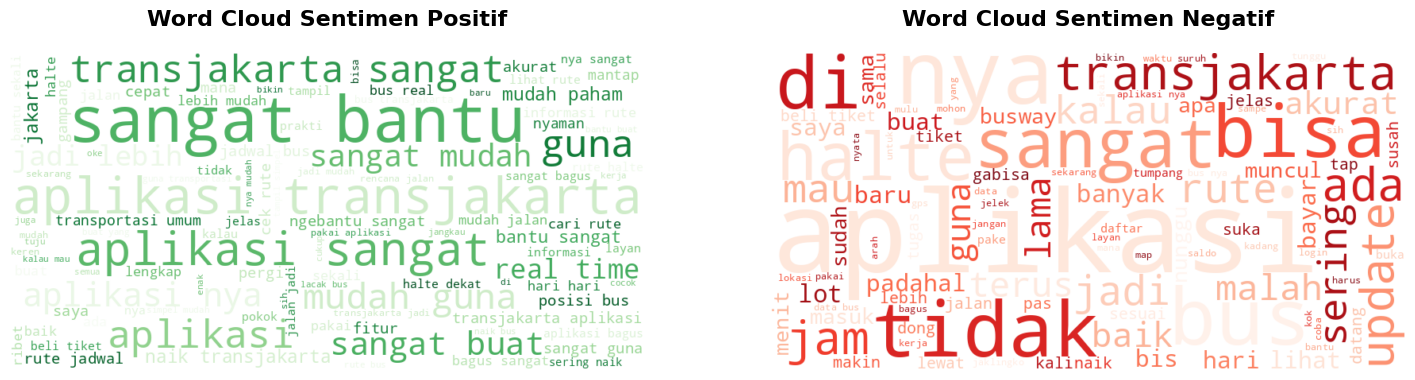

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Pisahkan teks berdasarkan sentimen
# Label 1 = Positif, Label 2 = Negatif
positif_text = ' '.join(df_final[df_final['label'] == 1]['tfidf_input'])
negatif_text = ' '.join(df_final[df_final['label'] == 2]['tfidf_input'])

# 2. Pengaturan properti Word Cloud
wordcloud_pos = WordCloud(width=800, height=400, background_color='white',
                          colormap='Greens', max_words=100, random_state=42)
wordcloud_neg = WordCloud(width=800, height=400, background_color='white',
                          colormap='Reds', max_words=100, random_state=42)

# 3. Generate Word Cloud
wordcloud_pos.generate(positif_text)
wordcloud_neg.generate(negatif_text)

# 4. Plotting Visualisasi Berdampingan
fig, ax = plt.subplots(1, 2, figsize=(18, 10))

# Word Cloud Positif
ax[0].imshow(wordcloud_pos, interpolation='bilinear')
ax[0].set_title('Word Cloud Sentimen Positif', fontsize=16, fontweight='bold', pad=20)
ax[0].axis('off')

# Word Cloud Negatif
ax[1].imshow(wordcloud_neg, interpolation='bilinear')
ax[1].set_title('Word Cloud Sentimen Negatif', fontsize=16, fontweight='bold', pad=20)
ax[1].axis('off')

# Simpan gambar untuk lampiran/bab 4 skripsi
plt.savefig('wordcloud_sentimen.png', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
%whos

Variable                 Type               Data/Info
-----------------------------------------------------
ConfusionMatrixDisplay   type               <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
SMOTE                    ABCMeta            <class 'imblearn.over_sam<...>pling._smote.base.SMOTE'>
SVC                      ABCMeta            <class 'sklearn.svm._classes.SVC'>
Sort                     EnumType           <enum 'Sort'>
StemmerFactory           type               <class 'Sastrawi.Stemmer.<...>rFactory.StemmerFactory'>
StopWordRemoverFactory   type               <class 'Sastrawi.StopWord<...>.StopWordRemoverFactory'>
TfidfVectorizer          type               <class 'sklearn.feature_e<...>on.text.TfidfVectorizer'>
WordCloud                type               <class 'wordcloud.wordcloud.WordCloud'>
X                        TfidfVectorizer    TfidfVectorizer()
ax                       ndarray            2: 2 elems, type `object`, 16 bytes
case_folding             func

**Split Data**

In [ ]:
import collections
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# =====================================================================
# 1. TAHAP TF-IDF (MEMASTIKAN X DAN y TERBENTUK DENGAN BENAR)
# =====================================================================
# Bersihkan baris yang tidak memiliki label
df_final = df_final.dropna(subset=["label"])

# Ubah list stemming menjadi gabungan string tekstual
df_final["tfidf_input"] = df_final["stemming"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else str(x)
)

# Ekstraksi fitur menggunakan TfidfVectorizer
tfidf = TfidfVectorizer()

# Variabel X murni diisi oleh hasil MATRIKS .fit_transform()
X_matrix = tfidf.fit_transform(df_final["tfidf_input"])

# Jaga sinkronisasi data dengan mengambil label dari DataFrame yang sama
y_vector = df_final["label"]

print("--- PROSES EKSTRAKSI FITUR SELESAI ---")
print(f"Dimensi Matriks Fitur (X): {X_matrix.shape}")
print(f"Jumlah Baris Label    (y): {y_vector.shape[0]}\n")


# =====================================================================
# 2. SKENARIO 1: Pembagian Data 80:20 & SMOTE
# =====================================================================
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X_matrix, y_vector, test_size=0.20, random_state=42, stratify=y_vector
)

smote = SMOTE(random_state=42)
X_train_80_smote, y_train_80_smote = smote.fit_resample(X_train_80, y_train_80)


# =====================================================================
# 3. SKENARIO 2: Pembagian Data 70:30 & SMOTE
# =====================================================================
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X_matrix, y_vector, test_size=0.30, random_state=42, stratify=y_vector
)

X_train_70_smote, y_train_70_smote = smote.fit_resample(X_train_70, y_train_70)


# =====================================================================
# 4. CETAK HASIL LOG UNTUK MEMASTIKAN BERHASIL 100%
# =====================================================================
print("====================================================================")
print("HASIL PEMBAGIAN DATASET & IMPLEMENTASI SMOTE")
print("====================================================================")
print("SKENARIO 1 (80:20)")
print(f"  - Data Uji / Testing Asli (20%)   : {X_test_20.shape[0]} ulasan")
print(
    f"  - Data Latih Asli Sebelum SMOTE   : {X_train_80.shape[0]} ulasan {dict(collections.Counter(y_train_80))}"
)
print(
    f"  - Data Latih Seimbang Sesudah SMOTE: {X_train_80_smote.shape[0]} ulasan {dict(collections.Counter(y_train_80_smote))}"
)
print("--------------------------------------------------------------------")
print("SKENARIO 2 (70:30)")
print(f"  - Data Uji / Testing Asli (30%)   : {X_test_30.shape[0]} ulasan")
print(
    f"  - Data Latih Asli Sebelum SMOTE   : {X_train_70.shape[0]} ulasan {dict(collections.Counter(y_train_70))}"
)
print(
    f"  - Data Latih Seimbang Sesudah SMOTE: {X_train_70_smote.shape[0]} ulasan {dict(collections.Counter(y_train_70_smote))}"
)
print("====================================================================")

--- PROSES EKSTRAKSI FITUR SELESAI ---
Dimensi Matriks Fitur (X): (2463, 2698)
Jumlah Baris Label    (y): 2463

HASIL PEMBAGIAN DATASET & IMPLEMENTASI SMOTE
SKENARIO 1 (80:20)
  - Data Uji / Testing Asli (20%)   : 493 ulasan
  - Data Latih Asli Sebelum SMOTE   : 1970 ulasan {2.0: 424, 1.0: 1546}
  - Data Latih Seimbang Sesudah SMOTE: 3092 ulasan {2.0: 1546, 1.0: 1546}
--------------------------------------------------------------------
SKENARIO 2 (70:30)
  - Data Uji / Testing Asli (30%)   : 739 ulasan
  - Data Latih Asli Sebelum SMOTE   : 1724 ulasan {1.0: 1353, 2.0: 371}
  - Data Latih Seimbang Sesudah SMOTE: 2706 ulasan {1.0: 1353, 2.0: 1353}


CLASSIFICATION REPORT SVM - SKENARIO 80:20
              precision    recall  f1-score   support

 Positif (1)       0.98      0.98      0.98       387
 Negatif (2)       0.92      0.92      0.92       106

    accuracy                           0.96       493
   macro avg       0.95      0.95      0.95       493
weighted avg       0.96      0.96      0.96       493


CLASSIFICATION REPORT SVM - SKENARIO 70:30
              precision    recall  f1-score   support

 Positif (1)       0.98      0.97      0.97       580
 Negatif (2)       0.90      0.92      0.91       159

    accuracy                           0.96       739
   macro avg       0.94      0.95      0.94       739
weighted avg       0.96      0.96      0.96       739



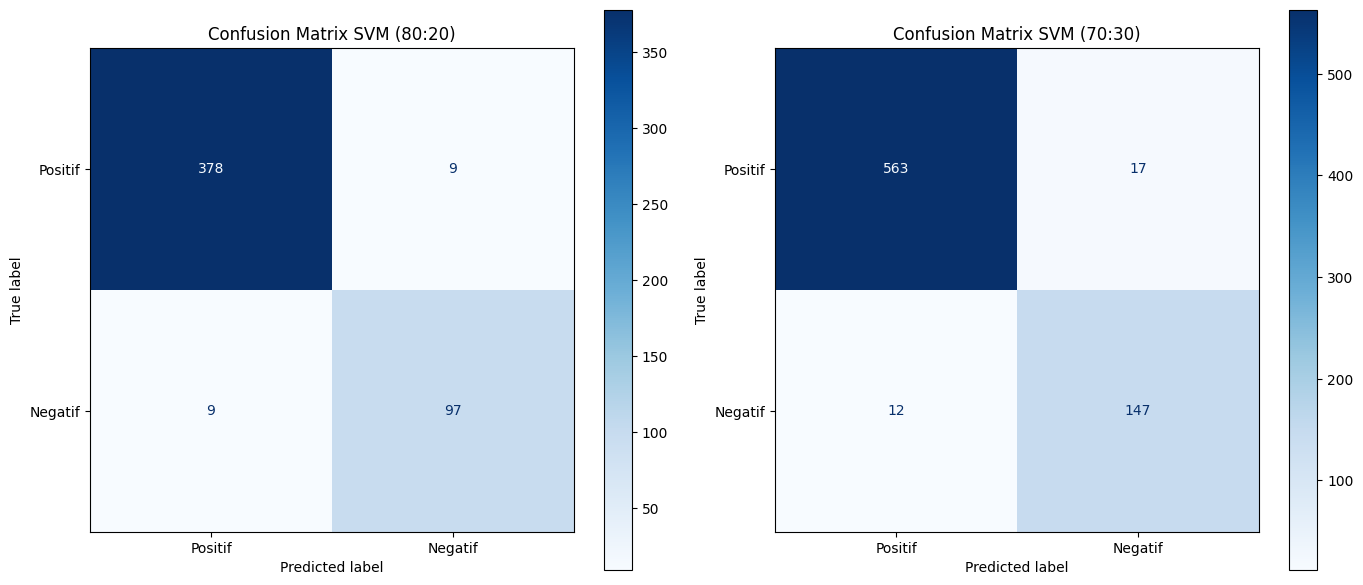

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Inisialisasi Model SVM dengan kernel linear
svm_model = SVC(kernel='linear', random_state=42)

# --- SKENARIO 1: 80:20 ---
# Catatan: Kita gunakan label asli (1: Positif, 2: Negatif) karena SVM tidak sensitif indeks 0
svm_model.fit(X_train_80_smote, y_train_80_smote)
y_pred_80 = svm_model.predict(X_test_20)

print("=======================================================")
print("CLASSIFICATION REPORT SVM - SKENARIO 80:20")
print("=======================================================")
print(classification_report(y_test_20, y_pred_80, target_names=['Positif (1)', 'Negatif (2)']))

# --- SKENARIO 2: 70:30 ---
svm_model.fit(X_train_70_smote, y_train_70_smote)
y_pred_70 = svm_model.predict(X_test_30)

print("\n=======================================================")
print("CLASSIFICATION REPORT SVM - SKENARIO 70:30")
print("=======================================================")
print(classification_report(y_test_30, y_pred_70, target_names=['Positif (1)', 'Negatif (2)']))

# --- PLOT CONFUSION MATRIX BERDAMPINGAN ---
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Skenario 80:20
cm_80 = confusion_matrix(y_test_20, y_pred_80)
disp_80 = ConfusionMatrixDisplay(confusion_matrix=cm_80, display_labels=['Positif', 'Negatif'])
disp_80.plot(ax=ax[0], cmap='Blues', values_format='d')
ax[0].set_title('Confusion Matrix SVM (80:20)')

# Skenario 70:30
cm_70 = confusion_matrix(y_test_30, y_pred_70)
disp_70 = ConfusionMatrixDisplay(confusion_matrix=cm_70, display_labels=['Positif', 'Negatif'])
disp_70.plot(ax=ax[1], cmap='Blues', values_format='d')
ax[1].set_title('Confusion Matrix SVM (70:30)')

plt.tight_layout()
plt.savefig('confusion_matrix_svm.png', dpi=300, bbox_inches='tight')
plt.show()

TABEL METRIKS EVALUASI SVM - SKENARIO 80:20


,precision,recall,f1-score,support
Positif (1),0.9767,0.9767,0.9767,387.0000
Negatif (2),0.9151,0.9151,0.9151,106.0000
accuracy,0.9635,0.9635,0.9635,0.9635
macro avg,0.9459,0.9459,0.9459,493.0000
weighted avg,0.9635,0.9635,0.9635,493.0000



TABEL METRIKS EVALUASI SVM - SKENARIO 70:30


,precision,recall,f1-score,support
Positif (1),0.9791,0.9707,0.9749,580.0000
Negatif (2),0.8963,0.9245,0.9102,159.0000
accuracy,0.9608,0.9608,0.9608,0.9608
macro avg,0.9377,0.9476,0.9426,739.0000
weighted avg,0.9613,0.9608,0.9610,739.0000


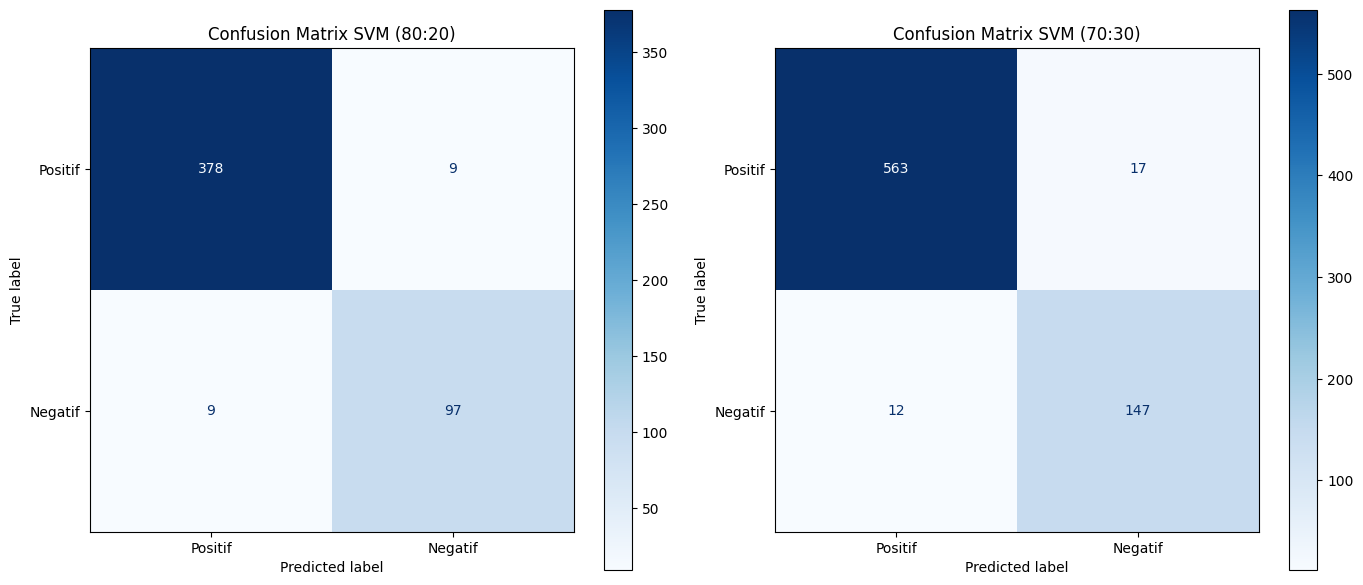

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# 1. Inisialisasi Model SVM dengan kernel linear
svm_model = SVC(kernel='linear', random_state=42)

# =====================================================================
# FUNCTION UNTUK MENGUBAH REPORT MENJADI TABEL DF (PERSIK SEPERTI DI SS)
# =====================================================================
def report_to_df(y_true, y_pred):
    report_dict = classification_report(y_true, y_pred, target_names=['Positif (1)', 'Negatif (2)'], output_dict=True)
    df_report = pd.DataFrame(report_dict).transpose()
    # Membulatkan nilai desimal menjadi 2 angka di belakang koma biar rapi
    return df_report.round(4)

# =====================================================================
# SKENARIO 1: 80:20
# =====================================================================
svm_model.fit(X_train_80_smote, y_train_80_smote)
y_pred_80 = svm_model.predict(X_test_20)

print("=======================================================")
print("TABEL METRIKS EVALUASI SVM - SKENARIO 80:20")
print("=======================================================")
df_report_80 = report_to_df(y_test_20, y_pred_80)
display(df_report_80) # Memaksa google colab menampilkan format tabel beneran

# =====================================================================
# SKENARIO 2: 70:30
# =====================================================================
svm_model.fit(X_train_70_smote, y_train_70_smote)
y_pred_70 = svm_model.predict(X_test_30)

print("\n=======================================================")
print("TABEL METRIKS EVALUASI SVM - SKENARIO 70:30")
print("=======================================================")
df_report_70 = report_to_df(y_test_30, y_pred_70)
display(df_report_70)

# =====================================================================
# PLOT CONFUSION MATRIX BERDAMPINGAN
# =====================================================================
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Skenario 80:20
cm_80 = confusion_matrix(y_test_20, y_pred_80)
disp_80 = ConfusionMatrixDisplay(confusion_matrix=cm_80, display_labels=['Positif', 'Negatif'])
disp_80.plot(ax=ax[0], cmap='Blues', values_format='d')
ax[0].set_title('Confusion Matrix SVM (80:20)')

# Skenario 70:30
cm_70 = confusion_matrix(y_test_30, y_pred_70)
disp_70 = ConfusionMatrixDisplay(confusion_matrix=cm_70, display_labels=['Positif', 'Negatif'])
disp_70.plot(ax=ax[1], cmap='Blues', values_format='d')
ax[1].set_title('Confusion Matrix SVM (70:30)')

plt.tight_layout()
plt.savefig('confusion_matrix_svm.png', dpi=300, bbox_inches='tight')
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:22:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


TABEL METRIKS EVALUASI XGBOOST - SKENARIO 80:20


,precision,recall,f1-score,support
Positif (1),0.9609,0.9535,0.9572,387.0000
Negatif (2),0.8349,0.8585,0.8465,106.0000
accuracy,0.9331,0.9331,0.9331,0.9331
macro avg,0.8979,0.9060,0.9019,493.0000
weighted avg,0.9338,0.9331,0.9334,493.0000


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:22:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



TABEL METRIKS EVALUASI XGBOOST - SKENARIO 70:30


,precision,recall,f1-score,support
Positif (1),0.9634,0.9517,0.9575,580.0000
Negatif (2),0.8313,0.8679,0.8492,159.0000
accuracy,0.9337,0.9337,0.9337,0.9337
macro avg,0.8973,0.9098,0.9034,739.0000
weighted avg,0.9349,0.9337,0.9342,739.0000


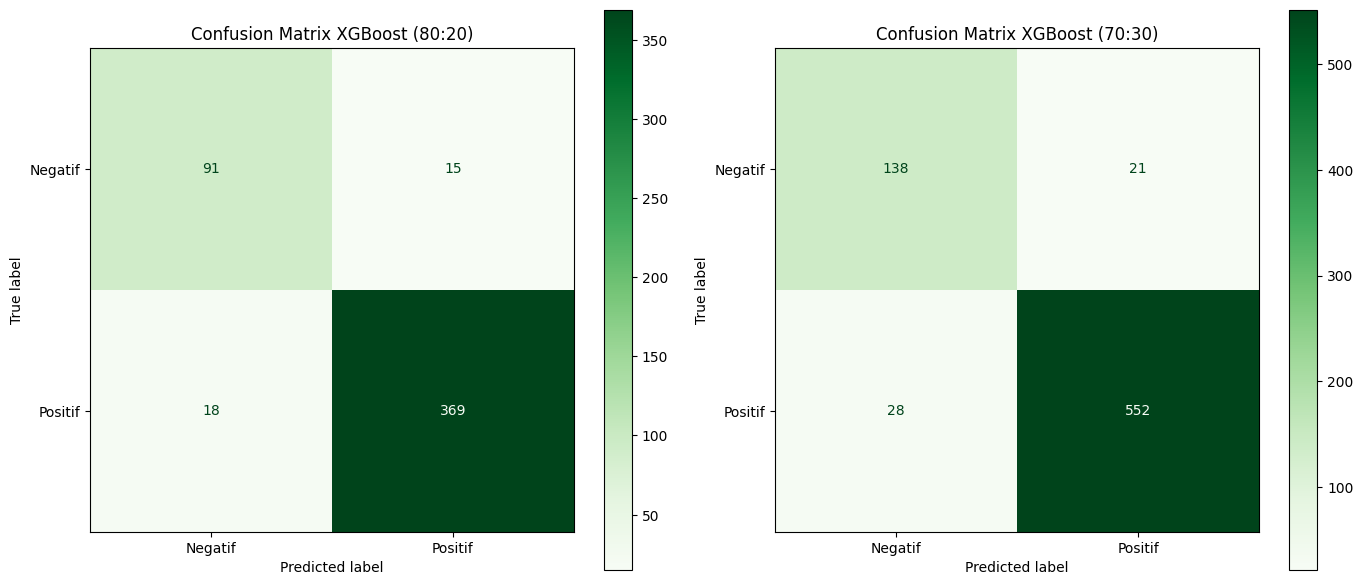

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# 1. Inisialisasi Model XGBoost
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# =====================================================================
# MENYESUAIKAN LABEL AGAR DIKENALI XGBOOST (1 & 2 -> 1 & 0)
# =====================================================================
# Mengubah label training skenario 1
y_train_80_xgb = y_train_80_smote.map({1.0: 1, 2.0: 0})
y_test_20_xgb = y_test_20.map({1.0: 1, 2.0: 0})

# Mengubah label training skenario 2
y_train_70_xgb = y_train_70_smote.map({1.0: 1, 2.0: 0})
y_test_30_xgb = y_test_30.map({1.0: 1, 2.0: 0})

# =====================================================================
# FUNCTION UNTUK MENGUBAH REPORT MENJADI TABEL DF DENGAN 4 DESIMAL
# =====================================================================
def report_to_df(y_true, y_pred):
    # Mengembalikan nama display di laporan agar tetap tertulis Positif (1) dan Negatif (2)
    report_dict = classification_report(y_true, y_pred, target_names=['Negatif (2)', 'Positif (1)'], output_dict=True)
    df_report = pd.DataFrame(report_dict).transpose()
    # Mengurutkan baris tabel agar Positif berada di atas seperti SVM sebelumnya
    df_report = df_report.reindex(['Positif (1)', 'Negatif (2)', 'accuracy', 'macro avg', 'weighted avg'])
    return df_report.round(4)

# =====================================================================
# KODE TRAINING & EVALUASI XGBoost - SKENARIO 1 (80:20)
# =====================================================================
xgb_model.fit(X_train_80_smote, y_train_80_xgb)
y_pred_xgb_80 = xgb_model.predict(X_test_20)

print("=======================================================")
print("TABEL METRIKS EVALUASI XGBOOST - SKENARIO 80:20")
print("=======================================================")
df_report_xgb_80 = report_to_df(y_test_20_xgb, y_pred_xgb_80)
display(df_report_xgb_80)

# =====================================================================
# KODE TRAINING & EVALUASI XGBoost - SKENARIO 2 (70:30)
# =====================================================================
xgb_model.fit(X_train_70_smote, y_train_70_xgb)
y_pred_xgb_70 = xgb_model.predict(X_test_30)

print("\n=======================================================")
print("TABEL METRIKS EVALUASI XGBOOST - SKENARIO 70:30")
print("=======================================================")
df_report_xgb_70 = report_to_df(y_test_30_xgb, y_pred_xgb_70)
display(df_report_xgb_70)

# =====================================================================
# PLOT CONFUSION MATRIX BERDAMPINGAN (CON MART)
# =====================================================================
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Skenario 80:20
cm_xgb_80 = confusion_matrix(y_test_20_xgb, y_pred_xgb_80)
disp_xgb_80 = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_80, display_labels=['Negatif', 'Positif'])
disp_xgb_80.plot(ax=ax[0], cmap='Greens', values_format='d')
ax[0].set_title('Confusion Matrix XGBoost (80:20)')

# Skenario 70:30
cm_xgb_70 = confusion_matrix(y_test_30_xgb, y_pred_xgb_70)
disp_xgb_70 = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_70, display_labels=['Negatif', 'Positif'])
disp_xgb_70.plot(ax=ax[1], cmap='Greens', values_format='d')
ax[1].set_title('Confusion Matrix XGBoost (70:30)')

plt.tight_layout()
plt.savefig('confusion_matrix_xgboost.png', dpi=300, bbox_inches='tight')
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00
TABEL METRIKS EVALUASI CATBOOST - SKENARIO 80:20


,precision,recall,f1-score,support
Positif (1),0.9708,0.9457,0.9581,387.0000
Negatif (2),0.8190,0.8962,0.8559,106.0000
accuracy,0.9351,0.9351,0.9351,0.9351
macro avg,0.8949,0.9210,0.9070,493.0000
weighted avg,0.9382,0.9351,0.9361,493.0000



TABEL METRIKS EVALUASI CATBOOST - SKENARIO 70:30


,precision,recall,f1-score,support
Positif (1),0.9766,0.9362,0.9560,580.0000
Negatif (2),0.7978,0.9182,0.8538,159.0000
accuracy,0.9323,0.9323,0.9323,0.9323
macro avg,0.8872,0.9272,0.9049,739.0000
weighted avg,0.9381,0.9323,0.9340,739.0000


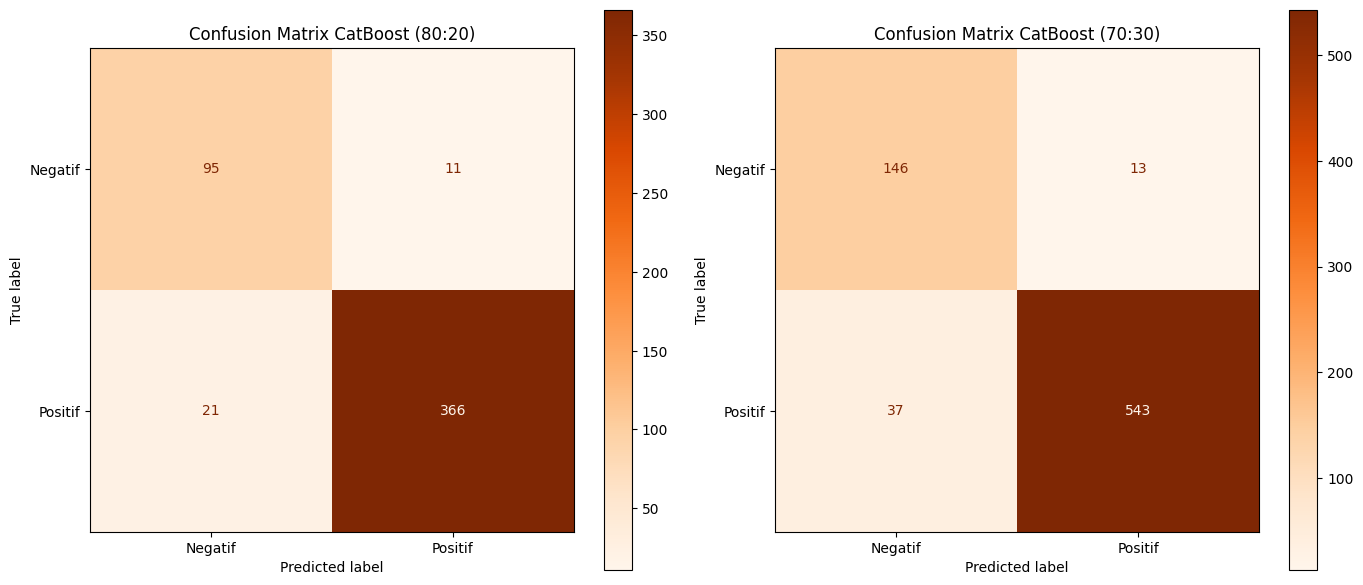

In [ ]:
# 1. Install library CatBoost terlebih dahulu jika belum ada
!pip install catboost

from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# 2. Inisialisasi Model CatBoost
# verbose=0 digunakan agar log training yang panjang tidak memenuhi layar Colab kamu
cat_model = CatBoostClassifier(random_state=42, verbose=0)

# =====================================================================
# MENYESUAIKAN LABEL KHUSUS UNTUK CATBOOST (1 & 2 -> 1 & 0)
# =====================================================================
y_train_80_cat = y_train_80_smote.map({1.0: 1, 2.0: 0})
y_test_20_cat = y_test_20.map({1.0: 1, 2.0: 0})

y_train_70_cat = y_train_70_smote.map({1.0: 1, 2.0: 0})
y_test_30_cat = y_test_30.map({1.0: 1, 2.0: 0})

# =====================================================================
# FUNCTION UNTUK MENGUBAH REPORT MENJADI TABEL DF DENGAN 4 DESIMAL
# =====================================================================
def report_to_df(y_true, y_pred):
    report_dict = classification_report(y_true, y_pred, target_names=['Negatif (2)', 'Positif (1)'], output_dict=True)
    df_report = pd.DataFrame(report_dict).transpose()
    df_report = df_report.reindex(['Positif (1)', 'Negatif (2)', 'accuracy', 'macro avg', 'weighted avg'])
    return df_report.round(4)

# =====================================================================
# KODE TRAINING & EVALUASI CatBoost - SKENARIO 1 (80:20)
# =====================================================================
cat_model.fit(X_train_80_smote, y_train_80_cat)
y_pred_cat_80 = cat_model.predict(X_test_20)

print("=======================================================")
print("TABEL METRIKS EVALUASI CATBOOST - SKENARIO 80:20")
print("=======================================================")
df_report_cat_80 = report_to_df(y_test_20_cat, y_pred_cat_80)
display(df_report_cat_80)

# =====================================================================
# KODE TRAINING & EVALUASI CatBoost - SKENARIO 2 (70:30)
# =====================================================================
cat_model.fit(X_train_70_smote, y_train_70_cat)
y_pred_cat_70 = cat_model.predict(X_test_30)

print("\n=======================================================")
print("TABEL METRIKS EVALUASI CATBOOST - SKENARIO 70:30")
print("=======================================================")
df_report_cat_70 = report_to_df(y_test_30_cat, y_pred_cat_70)
display(df_report_cat_70)

# =====================================================================
# PLOT CONFUSION MATRIX BERDAMPINGAN (CON MART)
# =====================================================================
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Skenario 80:20
cm_cat_80 = confusion_matrix(y_test_20_cat, y_pred_cat_80)
disp_cat_80 = ConfusionMatrixDisplay(confusion_matrix=cm_cat_80, display_labels=['Negatif', 'Positif'])
disp_cat_80.plot(ax=ax[0], cmap='Oranges', values_format='d') # Warna oranye khusus CatBoost
ax[0].set_title('Confusion Matrix CatBoost (80:20)')

# Skenario 70:30
cm_cat_70 = confusion_matrix(y_test_30_cat, y_pred_cat_70)
disp_cat_70 = ConfusionMatrixDisplay(confusion_matrix=cm_cat_70, display_labels=['Negatif', 'Positif'])
disp_cat_70.plot(ax=ax[1], cmap='Oranges', values_format='d')
ax[1].set_title('Confusion Matrix CatBoost (70:30)')

plt.tight_layout()
plt.savefig('confusion_matrix_catboost.png', dpi=300, bbox_inches='tight')
plt.show()